In [ ]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

if ROBOFLOW_API_KEY:
    print("✅ Chave do Roboflow carregada com segurança.")
else:
    print("❌ Chave não encontrada.")

✅ Chave do Roboflow carregada com segurança.


In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.6/333.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("ana-gesser")
project = workspace.project("tobacco-disease-classification-tlqjv")
version = project.version(1)

dataset = version.download(
    "folder",
    location="/content/roboflow_tobacco"
)

print("\n✅ Download concluído!")
print("Local:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/roboflow_tobacco in folder:: 100%|██████████| 443/443 [00:01<00:00, 241.23it/s]



✅ Download concluído!
Local: /content/roboflow_tobacco


In [ ]:
from pathlib import Path

ROOT = Path("/content/roboflow_tobacco")

print("=" * 60)
print("ESTRUTURA DO DATASET ROBOFLOW")
print("=" * 60)

for pasta in sorted(ROOT.rglob("*")):
    if pasta.is_dir():
        arquivos = [
            p for p in pasta.iterdir()
            if p.is_file() and not p.name.startswith(".")
        ]

        nivel = len(pasta.relative_to(ROOT).parts)
        indentacao = "    " * nivel

        print(f"{indentacao}📁 {pasta.name}/", end="")

        if arquivos:
            print(f"  → {len(arquivos)} arquivos")
        else:
            print()

ESTRUTURA DO DATASET ROBOFLOW
    📁 test/
        📁 CMV/  → 22 arquivos
        📁 Healthy/  → 2 arquivos
        📁 PVY/  → 5 arquivos
        📁 TMV/  → 3 arquivos
        📁 blackshank/  → 6 arquivos
        📁 wildfire/  → 10 arquivos
    📁 train/
        📁 CMV/  → 135 arquivos
        📁 Healthy/  → 12 arquivos
        📁 PVY/  → 32 arquivos
        📁 TMV/  → 9 arquivos
        📁 Tagetspot/  → 2 arquivos
        📁 bacterialwilt/  → 18 arquivos
        📁 blackshank/  → 21 arquivos
        📁 wildfire/  → 69 arquivos
    📁 valid/
        📁 CMV/  → 43 arquivos
        📁 Healthy/  → 3 arquivos
        📁 PVY/  → 9 arquivos
        📁 TMV/  → 4 arquivos
        📁 Tagetspot/  → 2 arquivos
        📁 bacterialwilt/  → 5 arquivos
        📁 blackshank/  → 8 arquivos
        📁 wildfire/  → 22 arquivos


In [ ]:
from pathlib import Path
from collections import defaultdict

ROOT = Path("/content/roboflow_tobacco")

splits = ["train", "valid", "test"]
extensoes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

contagem = defaultdict(dict)
todas_classes = set()

for split in splits:
    split_dir = ROOT / split

    for classe_dir in split_dir.iterdir():
        if not classe_dir.is_dir():
            continue

        classe = classe_dir.name
        todas_classes.add(classe)

        imagens = [
            p for p in classe_dir.iterdir()
            if p.is_file() and p.suffix.lower() in extensoes
        ]

        contagem[classe][split] = len(imagens)

print("=" * 65)
print("CONTAGEM POR CLASSE E SPLIT")
print("=" * 65)

print(f"{'Classe':20} {'Train':>8} {'Valid':>8} {'Test':>8} {'Total':>8}")
print("-" * 65)

total_geral = 0

for classe in sorted(todas_classes):
    train = contagem[classe].get("train", 0)
    valid = contagem[classe].get("valid", 0)
    test = contagem[classe].get("test", 0)
    total = train + valid + test

    total_geral += total

    print(
        f"{classe:20} "
        f"{train:>8} "
        f"{valid:>8} "
        f"{test:>8} "
        f"{total:>8}"
    )

print("-" * 65)

total_train = sum(contagem[c].get("train", 0) for c in todas_classes)
total_valid = sum(contagem[c].get("valid", 0) for c in todas_classes)
total_test = sum(contagem[c].get("test", 0) for c in todas_classes)

print(
    f"{'TOTAL':20} "
    f"{total_train:>8} "
    f"{total_valid:>8} "
    f"{total_test:>8} "
    f"{total_geral:>8}"
)

CONTAGEM POR CLASSE E SPLIT
Classe                  Train    Valid     Test    Total
-----------------------------------------------------------------
CMV                       135       43       22      200
Healthy                    12        3        2       17
PVY                        32        9        5       46
TMV                         9        4        3       16
Tagetspot                   2        2        0        4
bacterialwilt              18        5        0       23
blackshank                 21        8        6       35
wildfire                   69       22       10      101
-----------------------------------------------------------------
TOTAL                     298       96       48      442


In [ ]:
from pathlib import Path
from PIL import Image
from collections import defaultdict
import hashlib

ROOT = Path("/content/roboflow_tobacco")

splits = ["train", "valid", "test"]
extensoes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

registros = []
invalidas = []

# -----------------------------------
# Ler todas as imagens
# -----------------------------------

for split in splits:
    split_dir = ROOT / split

    for classe_dir in split_dir.iterdir():
        if not classe_dir.is_dir():
            continue

        classe = classe_dir.name

        for caminho in classe_dir.iterdir():
            if (
                not caminho.is_file()
                or caminho.suffix.lower() not in extensoes
            ):
                continue

            # Verificar integridade
            try:
                with Image.open(caminho) as img:
                    img.verify()
            except Exception as e:
                invalidas.append((split, classe, caminho.name, str(e)))
                continue

            # SHA-256
            with open(caminho, "rb") as f:
                sha256 = hashlib.sha256(f.read()).hexdigest()

            registros.append({
                "split": split,
                "classe": classe,
                "arquivo": caminho.name,
                "caminho": caminho,
                "sha256": sha256
            })


# -----------------------------------
# Procurar duplicatas exatas
# -----------------------------------

por_hash = defaultdict(list)

for r in registros:
    por_hash[r["sha256"]].append(r)

duplicatas = {
    h: itens
    for h, itens in por_hash.items()
    if len(itens) > 1
}

duplicatas_entre_splits = {}

for h, itens in duplicatas.items():
    splits_encontrados = {item["split"] for item in itens}

    if len(splits_encontrados) > 1:
        duplicatas_entre_splits[h] = itens


# -----------------------------------
# Relatório
# -----------------------------------

print("=" * 65)
print("VERIFICAÇÃO DE INTEGRIDADE")
print("=" * 65)

print(f"Imagens analisadas: {len(registros)}")
print(f"Imagens inválidas: {len(invalidas)}")
print(f"Grupos de duplicatas exatas: {len(duplicatas)}")
print(
    "Duplicatas exatas entre splits:",
    len(duplicatas_entre_splits)
)


# Mostrar inválidas
if invalidas:
    print("\nIMAGENS INVÁLIDAS:")

    for item in invalidas[:20]:
        print(item)


# Mostrar duplicatas entre splits
if duplicatas_entre_splits:
    print("\nDUPLICATAS ENTRE SPLITS:")

    for i, (hash_img, itens) in enumerate(
        duplicatas_entre_splits.items(), start=1
    ):
        print(f"\nGrupo {i}:")

        for item in itens:
            print(
                f"  {item['split']:5} | "
                f"{item['classe']:15} | "
                f"{item['arquivo']}"
            )

        if i >= 20:
            print("\n... mostrando apenas os primeiros 20 grupos.")
            break

VERIFICAÇÃO DE INTEGRIDADE
Imagens analisadas: 442
Imagens inválidas: 0
Grupos de duplicatas exatas: 0
Duplicatas exatas entre splits: 0


In [ ]:
!pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import imagehash
from collections import defaultdict

# Calcular pHash das 442 imagens
registros_phash = []

for r in registros:
    try:
        with Image.open(r["caminho"]) as img:
            phash = imagehash.phash(img.convert("RGB"))

        registros_phash.append({
            "split": r["split"],
            "classe": r["classe"],
            "arquivo": r["arquivo"],
            "caminho": r["caminho"],
            "phash": phash
        })

    except Exception as e:
        print("Erro:", r["arquivo"], e)


# Comparar imagens de splits diferentes
possiveis_duplicatas = []

for i in range(len(registros_phash)):
    a = registros_phash[i]

    for j in range(i + 1, len(registros_phash)):
        b = registros_phash[j]

        # Nosso principal interesse é vazamento entre splits
        if a["split"] == b["split"]:
            continue

        distancia = a["phash"] - b["phash"]

        # Quanto menor, mais parecidas
        if distancia <= 5:
            possiveis_duplicatas.append({
                "distancia": distancia,
                "a": a,
                "b": b
            })


possiveis_duplicatas.sort(
    key=lambda x: x["distancia"]
)


print("=" * 70)
print("POSSÍVEIS DUPLICATAS VISUAIS ENTRE SPLITS")
print("=" * 70)

print(
    "Pares encontrados com distância pHash <= 5:",
    len(possiveis_duplicatas)
)


for i, item in enumerate(possiveis_duplicatas[:30], start=1):

    a = item["a"]
    b = item["b"]

    print(f"\nPar {i} | distância: {item['distancia']}")

    print(
        f"  A: {a['split']:5} | "
        f"{a['classe']:15} | "
        f"{a['arquivo']}"
    )

    print(
        f"  B: {b['split']:5} | "
        f"{b['classe']:15} | "
        f"{b['arquivo']}"
    )

POSSÍVEIS DUPLICATAS VISUAIS ENTRE SPLITS
Pares encontrados com distância pHash <= 5: 4

Par 1 | distância: 0
  A: train | Healthy         | healthy-2-_jpg.rf.41274ac4f9dabcdd9fb69358b9e24566.jpg
  B: valid | Healthy         | healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg

Par 2 | distância: 0
  A: train | CMV             | haungguahuayebing-32-_JPG.rf.d57d83f50b7598beb75395b1d9ed7571.jpg
  B: test  | CMV             | haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg

Par 3 | distância: 4
  A: train | Healthy         | healthy-4-_jpg.rf.654772eb501c2965cd4b9ed5b64cad07.jpg
  B: valid | Healthy         | healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg

Par 4 | distância: 4
  A: train | blackshank      | heijingbing-15-_jpg.rf.c6af710ada1706bf2b560eea1eac9ad0.jpg
  B: valid | blackshank      | heijingbing-14-_jpg.rf.1366ed2d01abfc2fc9b19086a2e3bead.jpg


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

quantidade = len(possiveis_duplicatas)

fig, axes = plt.subplots(
    quantidade,
    2,
    figsize=(12, 5 * quantidade)
)

# Caso exista apenas 1 par
if quantidade == 1:
    axes = [axes]

for i, item in enumerate(possiveis_duplicatas):

    a = item["a"]
    b = item["b"]
    distancia = item["distancia"]

    img_a = Image.open(a["caminho"]).convert("RGB")
    img_b = Image.open(b["caminho"]).convert("RGB")

    axes[i][0].imshow(img_a)
    axes[i][0].set_title(
        f"A — {a['split']} / {a['classe']}\n"
        f"{a['arquivo']}\n"
        f"pHash distância = {distancia}",
        fontsize=9
    )
    axes[i][0].axis("off")

    axes[i][1].imshow(img_b)
    axes[i][1].set_title(
        f"B — {b['split']} / {b['classe']}\n"
        f"{b['arquivo']}\n"
        f"pHash distância = {distancia}",
        fontsize=9
    )
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
pares_phash_zero = []

for i in range(len(registros_phash)):
    a = registros_phash[i]

    for j in range(i + 1, len(registros_phash)):
        b = registros_phash[j]

        distancia = a["phash"] - b["phash"]

        if distancia == 0:
            pares_phash_zero.append({
                "a": a,
                "b": b
            })

print("=" * 70)
print("PARES COM pHash IDÊNTICO NO DATASET INTEIRO")
print("=" * 70)

print("Quantidade de pares:", len(pares_phash_zero))

for i, item in enumerate(pares_phash_zero[:50], start=1):

    a = item["a"]
    b = item["b"]

    print(f"\nPar {i}")

    print(
        f" A: {a['split']:5} | "
        f"{a['classe']:15} | "
        f"{a['arquivo']}"
    )

    print(
        f" B: {b['split']:5} | "
        f"{b['classe']:15} | "
        f"{b['arquivo']}"
    )

if len(pares_phash_zero) > 50:
    print(
        f"\n... mais {len(pares_phash_zero) - 50} pares não exibidos."
    )

PARES COM pHash IDÊNTICO NO DATASET INTEIRO
Quantidade de pares: 5

Par 1
 A: train | Healthy         | healthy-2-_jpg.rf.41274ac4f9dabcdd9fb69358b9e24566.jpg
 B: valid | Healthy         | healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg

Par 2
 A: train | Healthy         | healthy-1-_jpg.rf.772096aacf6da4f9cacabac16bee5a71.jpg
 B: train | Healthy         | healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg

Par 3
 A: train | CMV             | haungguahuayebing-30-_JPG.rf.88226445ac4dd5cb4c28c89f90ddd9a7.jpg
 B: train | CMV             | haungguahuayebing-244-_jpg.rf.64f395d5fdb15692d732d68985271d19.jpg

Par 4
 A: train | CMV             | haungguahuayebing-32-_JPG.rf.d57d83f50b7598beb75395b1d9ed7571.jpg
 B: test  | CMV             | haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg

Par 5
 A: train | wildfire        | yehuobing-50-_JPG.rf.17da267cda7129d6404b7fabae5a5fe6.jpg
 B: train | wildfire        | yehuobing-82-_jpg.rf.a99d9376c3924f6766f7f541ed2687d9.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

quantidade = len(pares_phash_zero)

fig, axes = plt.subplots(
    quantidade,
    2,
    figsize=(12, 5 * quantidade)
)

if quantidade == 1:
    axes = [axes]

for i, item in enumerate(pares_phash_zero):

    a = item["a"]
    b = item["b"]

    img_a = Image.open(a["caminho"]).convert("RGB")
    img_b = Image.open(b["caminho"]).convert("RGB")

    axes[i][0].imshow(img_a)
    axes[i][0].set_title(
        f"A — {a['split']} / {a['classe']}\n"
        f"{a['arquivo']}",
        fontsize=8
    )
    axes[i][0].axis("off")

    axes[i][1].imshow(img_b)
    axes[i][1].set_title(
        f"B — {b['split']} / {b['classe']}\n"
        f"{b['arquivo']}",
        fontsize=8
    )
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from collections import Counter, defaultdict

nomes_base = defaultdict(list)

for r in registros:
    # Remove o identificador acrescentado pelo Roboflow
    nome = r["arquivo"]

    if ".rf." in nome:
        base = nome.split(".rf.")[0]
    else:
        base = Path(nome).stem

    # Normalização simples
    base = base.lower()

    nomes_base[base].append(r)

# Bases que aparecem mais de uma vez
repetidos = {
    base: itens
    for base, itens in nomes_base.items()
    if len(itens) > 1
}

print("=" * 70)
print("NOMES-BASE REPETIDOS")
print("=" * 70)

print("Imagens totais:", len(registros))
print("Nomes-base únicos:", len(nomes_base))
print("Nomes-base repetidos:", len(repetidos))

for i, (base, itens) in enumerate(
    sorted(repetidos.items()),
    start=1
):
    print(f"\nGrupo {i}: {base}")

    for item in itens:
        print(
            f"  {item['split']:5} | "
            f"{item['classe']:15} | "
            f"{item['arquivo']}"
        )

    if i >= 50:
        print("\n... mostrando somente os primeiros 50 grupos.")
        break

NOMES-BASE REPETIDOS
Imagens totais: 442
Nomes-base únicos: 439
Nomes-base repetidos: 3

Grupo 1: healthy-1-_jpg
  train | Healthy         | healthy-1-_jpg.rf.772096aacf6da4f9cacabac16bee5a71.jpg
  train | Healthy         | healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg

Grupo 2: healthy-2-_jpg
  train | Healthy         | healthy-2-_jpg.rf.41274ac4f9dabcdd9fb69358b9e24566.jpg
  valid | Healthy         | healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg

Grupo 3: images_jpg
  train | Healthy         | images_jpg.rf.9e39d08dba0c09d99cc8d9e7cd2f4048.jpg
  test  | Healthy         | images_jpg.rf.d60342f80dbec17a102a8ef351db5077.jpg


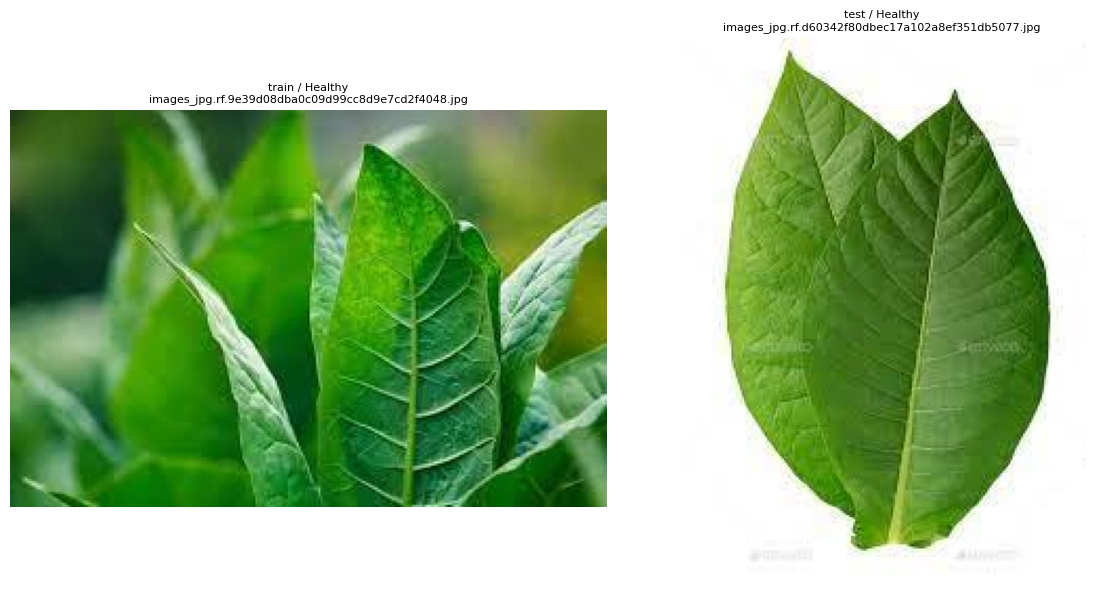

Distância pHash: 32


In [ ]:
grupo_images = repetidos["images_jpg"]

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, item in zip(axes, grupo_images):
    img = Image.open(item["caminho"]).convert("RGB")

    ax.imshow(img)
    ax.set_title(
        f"{item['split']} / {item['classe']}\n"
        f"{item['arquivo']}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# Também comparar o pHash desse par
with Image.open(grupo_images[0]["caminho"]) as img1:
    hash1 = imagehash.phash(img1.convert("RGB"))

with Image.open(grupo_images[1]["caminho"]) as img2:
    hash2 = imagehash.phash(img2.convert("RGB"))

print("Distância pHash:", hash1 - hash2)

In [ ]:
todos_pares_similares = []

for i in range(len(registros_phash)):
    a = registros_phash[i]

    for j in range(i + 1, len(registros_phash)):
        b = registros_phash[j]

        distancia = a["phash"] - b["phash"]

        if distancia <= 5:
            todos_pares_similares.append({
                "distancia": distancia,
                "a": a,
                "b": b
            })

todos_pares_similares.sort(
    key=lambda x: x["distancia"]
)

print("=" * 70)
print("SIMILARIDADE VISUAL NO DATASET INTEIRO")
print("=" * 70)

print("Total de imagens:", len(registros_phash))
print("Pares com pHash <= 5:", len(todos_pares_similares))

# Contagem por distância
from collections import Counter

distancias = Counter(
    item["distancia"]
    for item in todos_pares_similares
)

print("\nPor distância:")

for distancia in sorted(distancias):
    print(
        f"pHash {distancia}: "
        f"{distancias[distancia]} pares"
    )

# Quantos atravessam splits
entre_splits = [
    item for item in todos_pares_similares
    if item["a"]["split"] != item["b"]["split"]
]

print(
    "\nPares entre splits:",
    len(entre_splits)
)

# Quantos estão dentro do mesmo split
mesmo_split = [
    item for item in todos_pares_similares
    if item["a"]["split"] == item["b"]["split"]
]

print(
    "Pares dentro do mesmo split:",
    len(mesmo_split)
)

SIMILARIDADE VISUAL NO DATASET INTEIRO
Total de imagens: 442
Pares com pHash <= 5: 8

Por distância:
pHash 0: 5 pares
pHash 4: 3 pares

Pares entre splits: 4
Pares dentro do mesmo split: 4


In [ ]:
# Identificar todas as imagens envolvidas nos pares similares

imagens_suspeitas = {}

for item in todos_pares_similares:
    for lado in ["a", "b"]:
        img = item[lado]

        chave = str(img["caminho"])

        imagens_suspeitas[chave] = {
            "split": img["split"],
            "classe": img["classe"],
            "arquivo": img["arquivo"]
        }

print("=" * 70)
print("IMAGENS ENVOLVIDAS EM POSSÍVEIS DUPLICAÇÕES")
print("=" * 70)

print("Total do dataset:", len(registros_phash))
print("Pares com pHash <= 5:", len(todos_pares_similares))
print("Imagens únicas envolvidas:", len(imagens_suspeitas))

print("\nLista:")

for i, img in enumerate(imagens_suspeitas.values(), start=1):
    print(
        f"{i:2}. "
        f"{img['split']:5} | "
        f"{img['classe']:15} | "
        f"{img['arquivo']}"
    )

IMAGENS ENVOLVIDAS EM POSSÍVEIS DUPLICAÇÕES
Total do dataset: 442
Pares com pHash <= 5: 8
Imagens únicas envolvidas: 13

Lista:
 1. train | Healthy         | healthy-2-_jpg.rf.41274ac4f9dabcdd9fb69358b9e24566.jpg
 2. valid | Healthy         | healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg
 3. train | Healthy         | healthy-1-_jpg.rf.772096aacf6da4f9cacabac16bee5a71.jpg
 4. train | Healthy         | healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg
 5. train | CMV             | haungguahuayebing-30-_JPG.rf.88226445ac4dd5cb4c28c89f90ddd9a7.jpg
 6. train | CMV             | haungguahuayebing-244-_jpg.rf.64f395d5fdb15692d732d68985271d19.jpg
 7. train | CMV             | haungguahuayebing-32-_JPG.rf.d57d83f50b7598beb75395b1d9ed7571.jpg
 8. test  | CMV             | haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg
 9. train | wildfire        | yehuobing-50-_JPG.rf.17da267cda7129d6404b7fabae5a5fe6.jpg
10. train | wildfire        | yehuobing-82-_jpg.rf.a99d937

ROBOFLOW — RESULTADO ATÉ AGORA

Total:                         442 imagens
Classes:                         8
Imagens inválidas:               0
Duplicatas exatas SHA-256:       0

pHash ≤ 5:
├─ Pares suspeitos:              8
├─ Imagens envolvidas:          13
├─ Pares entre splits:           4 ⚠️
└─ Pares no mesmo split:         4

Conclusão:
⚠️ existem repetições/near-duplicates
⚠️ existe vazamento entre os splits originais

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

TPDD_ROOT = Path(
    "/content/drive/MyDrive/SafraCerta/TPDD_Honglin_CLS_YOLO"
)

print("Pasta encontrada:", TPDD_ROOT.exists())

if TPDD_ROOT.exists():
    print("✅ TPDD encontrado no Google Drive.")

    for split in ["train", "val", "test"]:
        caminho = TPDD_ROOT / split
        print(f"{split}: {caminho.exists()}")
else:
    print("❌ TPDD não encontrado.")

Mounted at /content/drive
Pasta encontrada: True
✅ TPDD encontrado no Google Drive.
train: True
val: True
test: True


In [ ]:
from pathlib import Path
from PIL import Image
import imagehash

TPDD_ROOT = Path(
    "/content/drive/MyDrive/SafraCerta/TPDD_Honglin_CLS_YOLO"
)

tpdd_registros = []

for split in ["train", "val", "test"]:
    split_dir = TPDD_ROOT / split

    for classe_dir in split_dir.iterdir():
        if not classe_dir.is_dir():
            continue

        for caminho in classe_dir.iterdir():
            if not caminho.is_file():
                continue

            if caminho.suffix.lower() not in {
                ".jpg", ".jpeg", ".png", ".bmp", ".webp"
            }:
                continue

            try:
                with Image.open(caminho) as img:
                    phash = imagehash.phash(img.convert("RGB"))

                tpdd_registros.append({
                    "split": split,
                    "classe": classe_dir.name,
                    "arquivo": caminho.name,
                    "caminho": caminho,
                    "phash": phash
                })

            except Exception as e:
                print("Erro:", caminho, e)

print("=" * 60)
print("TPDD CARREGADO PARA COMPARAÇÃO")
print("=" * 60)

print("Imagens encontradas:", len(tpdd_registros))

for split in ["train", "val", "test"]:
    quantidade = sum(
        1 for r in tpdd_registros
        if r["split"] == split
    )
    print(f"{split}: {quantidade}")

TPDD CARREGADO PARA COMPARAÇÃO
Imagens encontradas: 1571
train: 1295
val: 138
test: 138


In [ ]:
# Comparação Roboflow x TPDD
# Primeiro: apenas correspondências com pHash exatamente igual

matches_zero = []

for robo in registros_phash:
    for tpdd in tpdd_registros:

        distancia = robo["phash"] - tpdd["phash"]

        if distancia == 0:
            matches_zero.append({
                "distancia": distancia,
                "roboflow": robo,
                "tpdd": tpdd
            })

print("=" * 75)
print("ROBOFLOW x TPDD — pHash = 0")
print("=" * 75)

print("Imagens Roboflow:", len(registros_phash))
print("Imagens TPDD:", len(tpdd_registros))
print("Correspondências encontradas:", len(matches_zero))

# Quantas imagens diferentes do Roboflow tiveram match
robo_com_match = {
    str(item["roboflow"]["caminho"])
    for item in matches_zero
}

print(
    "Imagens únicas do Roboflow com correspondência:",
    len(robo_com_match)
)

# Mostrar os resultados
for i, item in enumerate(matches_zero[:50], start=1):

    r = item["roboflow"]
    t = item["tpdd"]

    print(f"\nMatch {i}")

    print(
        f" Roboflow: {r['split']:5} | "
        f"{r['classe']:15} | "
        f"{r['arquivo']}"
    )

    print(
        f" TPDD:     {t['split']:5} | "
        f"{t['classe']:15} | "
        f"{t['arquivo']}"
    )

if len(matches_zero) > 50:
    print(
        f"\n... mais {len(matches_zero) - 50} "
        "correspondências não exibidas."
    )

ROBOFLOW x TPDD — pHash = 0
Imagens Roboflow: 442
Imagens TPDD: 1571
Correspondências encontradas: 0
Imagens únicas do Roboflow com correspondência: 0


In [ ]:
matches_similares = []

for robo in registros_phash:
    for tpdd in tpdd_registros:

        distancia = robo["phash"] - tpdd["phash"]

        if distancia <= 5:
            matches_similares.append({
                "distancia": distancia,
                "roboflow": robo,
                "tpdd": tpdd
            })

matches_similares.sort(
    key=lambda x: x["distancia"]
)

print("=" * 75)
print("ROBOFLOW x TPDD — pHash <= 5")
print("=" * 75)

print("Imagens Roboflow:", len(registros_phash))
print("Imagens TPDD:", len(tpdd_registros))
print("Pares encontrados:", len(matches_similares))

# Imagens únicas do Roboflow envolvidas
robo_envolvidas = {
    str(item["roboflow"]["caminho"])
    for item in matches_similares
}

print(
    "Imagens únicas do Roboflow envolvidas:",
    len(robo_envolvidas)
)

# Contagem por distância
from collections import Counter

distancias = Counter(
    item["distancia"]
    for item in matches_similares
)

print("\nPor distância:")

for distancia in sorted(distancias):
    print(
        f"pHash {distancia}: "
        f"{distancias[distancia]} pares"
    )

# Mostrar os primeiros resultados
for i, item in enumerate(matches_similares[:30], start=1):

    r = item["roboflow"]
    t = item["tpdd"]

    print(f"\nPar {i} | distância: {item['distancia']}")

    print(
        f" Roboflow: {r['split']:5} | "
        f"{r['classe']:15} | "
        f"{r['arquivo']}"
    )

    print(
        f" TPDD:     {t['split']:5} | "
        f"{t['classe']:15} | "
        f"{t['arquivo']}"
    )

if len(matches_similares) > 30:
    print(
        f"\n... mais {len(matches_similares) - 30} "
        "pares não exibidos."
    )

ROBOFLOW x TPDD — pHash <= 5
Imagens Roboflow: 442
Imagens TPDD: 1571
Pares encontrados: 0
Imagens únicas do Roboflow envolvidas: 0

Por distância:


In [ ]:
from pathlib import Path
import shutil

ROBOFLOW_ORIGINAL = Path("/content/roboflow_tobacco")
ROBOFLOW_WORK = Path("/content/roboflow_tobacco_filtered")

# Mapeamento para os nomes padronizados do SafraCerta
MAPEAMENTO_CLASSES = {
    "CMV": "cmv",
    "Healthy": "healthy",
    "PVY": "pvy",
    "TMV": "tmv",
    "blackshank": "black_shank",
    "wildfire": "wildfire"
}

splits = ["train", "valid", "test"]

# Recriar pasta de trabalho caso a célula seja executada novamente
if ROBOFLOW_WORK.exists():
    shutil.rmtree(ROBOFLOW_WORK)

total_copiadas = 0

for split in splits:
    for classe_original, classe_nova in MAPEAMENTO_CLASSES.items():

        origem = ROBOFLOW_ORIGINAL / split / classe_original
        destino = ROBOFLOW_WORK / split / classe_nova

        destino.mkdir(parents=True, exist_ok=True)

        if not origem.exists():
            continue

        for arquivo in origem.iterdir():
            if arquivo.is_file():
                shutil.copy2(arquivo, destino / arquivo.name)
                total_copiadas += 1

print("=" * 60)
print("DATASET ROBOFLOW FILTRADO")
print("=" * 60)

print("Imagens copiadas:", total_copiadas)

for split in splits:
    quantidade = sum(
        1
        for p in (ROBOFLOW_WORK / split).rglob("*")
        if p.is_file()
    )

    print(f"{split}: {quantidade}")

DATASET ROBOFLOW FILTRADO
Imagens copiadas: 415
train: 278
valid: 89
test: 48


In [ ]:
from pathlib import Path
from PIL import Image
import imagehash

ROOT = Path("/content/roboflow_tobacco_filtered")

imagens = []

for split in ["train", "valid", "test"]:
    for arquivo in (ROOT / split).rglob("*"):
        if arquivo.is_file():
            try:
                with Image.open(arquivo) as img:
                    phash = imagehash.phash(img.convert("RGB"))

                imagens.append({
                    "split": split,
                    "classe": arquivo.parent.name,
                    "arquivo": arquivo.name,
                    "path": arquivo,
                    "phash": phash
                })
            except Exception:
                pass

pares = []

for i in range(len(imagens)):
    for j in range(i + 1, len(imagens)):
        distancia = imagens[i]["phash"] - imagens[j]["phash"]

        if distancia <= 5:
            pares.append((
                distancia,
                imagens[i],
                imagens[j]
            ))

pares.sort(key=lambda x: x[0])

print(f"Imagens analisadas: {len(imagens)}")
print(f"Pares com pHash <= 5: {len(pares)}")
print("=" * 80)

for distancia, a, b in pares:
    print(f"\npHash distance: {distancia}")
    print(f"A: [{a['split']}] [{a['classe']}] {a['arquivo']}")
    print(f"B: [{b['split']}] [{b['classe']}] {b['arquivo']}")

Imagens analisadas: 415
Pares com pHash <= 5: 8

pHash distance: 0
A: [train] [cmv] haungguahuayebing-30-_JPG.rf.88226445ac4dd5cb4c28c89f90ddd9a7.jpg
B: [train] [cmv] haungguahuayebing-244-_jpg.rf.64f395d5fdb15692d732d68985271d19.jpg

pHash distance: 0
A: [train] [cmv] haungguahuayebing-32-_JPG.rf.d57d83f50b7598beb75395b1d9ed7571.jpg
B: [test] [cmv] haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg

pHash distance: 0
A: [train] [wildfire] yehuobing-50-_JPG.rf.17da267cda7129d6404b7fabae5a5fe6.jpg
B: [train] [wildfire] yehuobing-82-_jpg.rf.a99d9376c3924f6766f7f541ed2687d9.jpg

pHash distance: 0
A: [train] [healthy] healthy-2-_jpg.rf.41274ac4f9dabcdd9fb69358b9e24566.jpg
B: [valid] [healthy] healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg

pHash distance: 0
A: [train] [healthy] healthy-1-_jpg.rf.772096aacf6da4f9cacabac16bee5a71.jpg
B: [train] [healthy] healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg

pHash distance: 4
A: [train] [black_shank] heijingbing-15-_

In [ ]:
from pathlib import Path

ROOT = Path("/content/roboflow_tobacco_filtered")

REMOVER = [
    # CMV - duplicata dentro do treino
    ROOT / "train/cmv/haungguahuayebing-244-_jpg.rf.64f395d5fdb15692d732d68985271d19.jpg",

    # CMV - duplicata entre train/test
    ROOT / "test/cmv/haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg",

    # Wildfire - duplicata dentro do treino
    ROOT / "train/wildfire/yehuobing-82-_jpg.rf.a99d9376c3924f6766f7f541ed2687d9.jpg",

    # Healthy - duplicata dentro do treino
    ROOT / "train/healthy/healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg",

    # Healthy - duplicata train/valid
    ROOT / "valid/healthy/healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg",

    # Healthy - near-duplicate
    ROOT / "train/healthy/healthy-4-_jpg.rf.654772eb501c2965cd4b9ed5b64cad07.jpg",

    # Black shank - near-duplicate train/valid
    ROOT / "valid/black_shank/heijingbing-14-_jpg.rf.1366ed2d01abfc2fc9b19086a2e3bead.jpg",
]

print("=" * 60)
print("REMOÇÃO DE DUPLICATAS")
print("=" * 60)

removidas = 0

for arquivo in REMOVER:
    if arquivo.exists():
        arquivo.unlink()
        removidas += 1
        print("REMOVIDO:", arquivo.relative_to(ROOT))
    else:
        print("NÃO ENCONTRADO:", arquivo.relative_to(ROOT))

print()
print("Total removido:", removidas)

# Conferência
total = 0

for split in ["train", "valid", "test"]:
    quantidade = sum(
        1 for p in (ROOT / split).rglob("*")
        if p.is_file()
    )

    total += quantidade
    print(f"{split}: {quantidade}")

print("TOTAL:", total)

REMOÇÃO DE DUPLICATAS
REMOVIDO: train/cmv/haungguahuayebing-244-_jpg.rf.64f395d5fdb15692d732d68985271d19.jpg
REMOVIDO: test/cmv/haungguahuayebing-246-_jpg.rf.c17d9eb8f16cbcd9574dd995c51f03d4.jpg
REMOVIDO: train/wildfire/yehuobing-82-_jpg.rf.a99d9376c3924f6766f7f541ed2687d9.jpg
REMOVIDO: train/healthy/healthy-1-_jpg.rf.0eff36b9bdfda8fe923096e8423fb930.jpg
REMOVIDO: valid/healthy/healthy-2-_jpg.rf.e4c46a057f797322cbf748803cfdb120.jpg
REMOVIDO: train/healthy/healthy-4-_jpg.rf.654772eb501c2965cd4b9ed5b64cad07.jpg
REMOVIDO: valid/black_shank/heijingbing-14-_jpg.rf.1366ed2d01abfc2fc9b19086a2e3bead.jpg

Total removido: 7
train: 274
valid: 87
test: 47
TOTAL: 408


In [ ]:
from pathlib import Path
from PIL import Image
import imagehash

ROOT = Path("/content/roboflow_tobacco_filtered")

imagens = []

for split in ["train", "valid", "test"]:
    for arquivo in (ROOT / split).rglob("*"):
        if arquivo.is_file():
            try:
                with Image.open(arquivo) as img:
                    phash = imagehash.phash(img.convert("RGB"))

                imagens.append({
                    "split": split,
                    "classe": arquivo.parent.name,
                    "arquivo": arquivo.name,
                    "phash": phash
                })
            except Exception:
                pass

pares = []

for i in range(len(imagens)):
    for j in range(i + 1, len(imagens)):
        distancia = imagens[i]["phash"] - imagens[j]["phash"]

        if distancia <= 5:
            pares.append((distancia, imagens[i], imagens[j]))

print("Imagens analisadas:", len(imagens))
print("Pares com pHash <= 5:", len(pares))

for distancia, a, b in pares:
    print()
    print("Distância:", distancia)
    print("A:", a["split"], a["classe"], a["arquivo"])
    print("B:", b["split"], b["classe"], b["arquivo"])

Imagens analisadas: 408
Pares com pHash <= 5: 0


In [ ]:
from pathlib import Path
from collections import defaultdict

ROOT = Path("/content/roboflow_tobacco_filtered")

contagem = defaultdict(dict)

for split in ["train", "valid", "test"]:
    pasta_split = ROOT / split

    for classe in sorted(p.name for p in pasta_split.iterdir() if p.is_dir()):
        quantidade = sum(
            1 for arquivo in (pasta_split / classe).iterdir()
            if arquivo.is_file()
        )

        contagem[classe][split] = quantidade

print("=" * 65)
print(f"{'CLASSE':<20} {'TRAIN':>8} {'VALID':>8} {'TEST':>8} {'TOTAL':>8}")
print("=" * 65)

total_geral = 0

for classe in sorted(contagem):
    train = contagem[classe].get("train", 0)
    valid = contagem[classe].get("valid", 0)
    test = contagem[classe].get("test", 0)
    total = train + valid + test

    total_geral += total

    print(f"{classe:<20} {train:>8} {valid:>8} {test:>8} {total:>8}")

print("=" * 65)
print(f"{'TOTAL':<20} {'274':>8} {'87':>8} {'47':>8} {total_geral:>8}")

CLASSE                  TRAIN    VALID     TEST    TOTAL
black_shank                21        7        6       34
cmv                       134       43       21      198
healthy                    10        2        2       14
pvy                        32        9        5       46
tmv                         9        4        3       16
wildfire                   68       22       10      100
TOTAL                     274       87       47      408


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

ORIGEM = Path("/content/roboflow_tobacco_filtered")
DESTINO = Path("/content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean")

if DESTINO.exists():
    shutil.rmtree(DESTINO)

shutil.copytree(ORIGEM, DESTINO)

print("Salvo em:", DESTINO)

for split in ["train", "valid", "test"]:
    qtd = sum(
        1 for p in (DESTINO / split).rglob("*")
        if p.is_file()
    )
    print(f"{split}: {qtd}")

total = sum(1 for p in DESTINO.rglob("*") if p.is_file())
print("TOTAL:", total)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvo em: /content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean
train: 274
valid: 87
test: 47
TOTAL: 408


In [ ]:
from pathlib import Path
from datetime import datetime

DATASET = Path("/content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean")
RELATORIO = DATASET / "DATASET_INFO.md"

conteudo = """# Roboflow Tobacco Disease Classification - Dataset Preparation

## Origem

- Plataforma: Roboflow Universe
- Projeto: Tobacco Disease Classification
- Dataset de origem: 442 imagens
- Versão utilizada: Version 1
- Preprocessamento adicional no Roboflow: nenhum
- Augmentation adicional no Roboflow: nenhum
- Licença informada na página pública: CC BY 4.0

Observação: a página pública do projeto não fornece documentação
suficiente sobre a origem original das imagens nem sobre o processo
utilizado para validar os rótulos. Portanto, a procedência das imagens
deve ser considerada uma limitação deste dataset.

## Classes selecionadas

As classes foram padronizadas para os nomes utilizados no projeto
SafraCerta:

- CMV -> cmv
- Healthy -> healthy
- PVY -> pvy
- TMV -> tmv
- blackshank -> black_shank
- wildfire -> wildfire

## Classes não utilizadas

- bacterialwilt: 23 imagens
  Motivo: classe não presente no TPDD e com poucas imagens.

- Tagetspot: 4 imagens
  Motivo: quantidade muito pequena de imagens adicionais.

Total descartado por seleção de classes: 27 imagens.

## Verificação de duplicatas

Foram verificadas duplicatas e imagens visualmente muito semelhantes
utilizando perceptual hash (pHash).

Antes da limpeza:

- 415 imagens das classes selecionadas
- 8 pares com distância pHash <= 5

Após inspeção dos pares, foram removidas 7 imagens duplicadas ou
near-duplicates.

Após a limpeza:

- 408 imagens
- 0 pares com distância pHash <= 5

O pHash é uma heurística e não garante a identificação de todas as
possíveis imagens derivadas, recortadas ou transformadas.

## Distribuição final

| Classe | Train | Valid | Test | Total |
|---|---:|---:|---:|---:|
| black_shank | 21 | 7 | 6 | 34 |
| cmv | 134 | 43 | 21 | 198 |
| healthy | 10 | 2 | 2 | 14 |
| pvy | 32 | 9 | 5 | 46 |
| tmv | 9 | 4 | 3 | 16 |
| wildfire | 68 | 22 | 10 | 100 |
| **TOTAL** | **274** | **87** | **47** | **408** |

## Limitações

1. O dataset é desbalanceado, principalmente entre CMV e classes como
   healthy e TMV.

2. A origem primária das imagens não está suficientemente documentada
   na página pública do projeto.

3. O processo original de validação dos rótulos não está documentado.

4. Nenhuma augmentation adicional foi aplicada na Version 1 criada
   para esta preparação. Isso não garante que todas as imagens do
   dataset-fonte sejam fotografias independentes ou que não tenham
   sofrido processamento antes de serem publicadas.

5. A busca por duplicatas utilizou SHA-256/pHash durante a análise.
   O pHash deve ser considerado uma verificação heurística.

## Uso no SafraCerta

Este dataset será utilizado como fonte complementar ao
TPDD_Honglin_CLS.

Os datasets originais serão mantidos separadamente. Uma versão
combinada deverá ser criada em outra pasta, preservando a identificação
da fonte de cada imagem.
"""

RELATORIO.write_text(conteudo, encoding="utf-8")

print("Relatório criado:")
print(RELATORIO)
print()
print("Tamanho:", RELATORIO.stat().st_size, "bytes")

Relatório criado:
/content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean/DATASET_INFO.md

Tamanho: 2888 bytes


In [ ]:
from pathlib import Path

TPDD = Path("/content/drive/MyDrive/SafraCerta/TPDD_Honglin_CLS_YOLO")
ROBO = Path("/content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean")

def obter_classes(root, splits):
    classes = set()

    for split in splits:
        pasta = root / split

        if pasta.exists():
            classes.update(
                p.name for p in pasta.iterdir()
                if p.is_dir()
            )

    return sorted(classes)


classes_tpdd = obter_classes(TPDD, ["train", "val", "test"])
classes_robo = obter_classes(ROBO, ["train", "valid", "test"])

print("=" * 60)
print("TPDD")
print("=" * 60)
print("Quantidade de classes:", len(classes_tpdd))
print(classes_tpdd)

print()
print("=" * 60)
print("ROBOFLOW")
print("=" * 60)
print("Quantidade de classes:", len(classes_robo))
print(classes_robo)

print()
print("=" * 60)
print("CLASSES EM COMUM")
print("=" * 60)

comuns = sorted(set(classes_tpdd) & set(classes_robo))

print("Quantidade:", len(comuns))
print(comuns)

TPDD
Quantidade de classes: 16
['anthracnose', 'black_shank', 'brown_spot', 'cmv', 'frog_eye', 'genetic_abnormality', 'healthy', 'nematodes', 'potato_tuber_moth', 'pvy', 'sunscald', 'target_spot', 'tmv', 'tswv', 'weather_fleck', 'wildfire']

ROBOFLOW
Quantidade de classes: 6
['black_shank', 'cmv', 'healthy', 'pvy', 'tmv', 'wildfire']

CLASSES EM COMUM
Quantidade: 6
['black_shank', 'cmv', 'healthy', 'pvy', 'tmv', 'wildfire']


In [ ]:
from pathlib import Path
import shutil

TPDD = Path("/content/drive/MyDrive/SafraCerta/TPDD_Honglin_CLS_YOLO")
ROBO = Path("/content/drive/MyDrive/SafraCerta/Roboflow_Tobacco_CLS_Clean")

COMBINADO = Path("/content/drive/MyDrive/SafraCerta/SafraCerta_Combined_CLS")

EXTENSOES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Evita sobrescrever algo sem perceber
if COMBINADO.exists():
    raise FileExistsError(
        f"A pasta já existe: {COMBINADO}\n"
        "Não foi alterado nenhum arquivo."
    )

splits_tpdd = {
    "train": "train",
    "val": "val",
    "test": "test"
}

splits_robo = {
    "train": "train",
    "val": "valid",
    "test": "test"
}

def copiar_dataset(origem, mapa_splits, prefixo):
    copiadas = 0

    for split_destino, split_origem in mapa_splits.items():

        pasta_split = origem / split_origem

        for pasta_classe in pasta_split.iterdir():

            if not pasta_classe.is_dir():
                continue

            destino = COMBINADO / split_destino / pasta_classe.name
            destino.mkdir(parents=True, exist_ok=True)

            for arquivo in pasta_classe.iterdir():

                if (
                    arquivo.is_file()
                    and arquivo.suffix.lower() in EXTENSOES
                ):
                    # Prefixo preserva a origem e evita colisões de nome
                    novo_nome = f"{prefixo}__{arquivo.name}"

                    shutil.copy2(
                        arquivo,
                        destino / novo_nome
                    )

                    copiadas += 1

    return copiadas


print("Copiando TPDD...")
n_tpdd = copiar_dataset(
    TPDD,
    splits_tpdd,
    "tpdd"
)

print("Copiando Roboflow...")
n_robo = copiar_dataset(
    ROBO,
    splits_robo,
    "roboflow"
)

print()
print("=" * 60)
print("DATASET COMBINADO")
print("=" * 60)

print("TPDD copiadas:", n_tpdd)
print("Roboflow copiadas:", n_robo)
print("TOTAL:", n_tpdd + n_robo)

print()

total_final = 0

for split in ["train", "val", "test"]:

    quantidade = sum(
        1
        for p in (COMBINADO / split).rglob("*")
        if p.is_file() and p.suffix.lower() in EXTENSOES
    )

    total_final += quantidade

    print(f"{split}: {quantidade}")

print("TOTAL VERIFICADO:", total_final)

Copiando TPDD...
Copiando Roboflow...

DATASET COMBINADO
TPDD copiadas: 1571
Roboflow copiadas: 408
TOTAL: 1979

train: 1569
val: 225
test: 185
TOTAL VERIFICADO: 1979


In [ ]:
from pathlib import Path

COMBINADO = Path(
    "/content/drive/MyDrive/SafraCerta/SafraCerta_Combined_CLS"
)

EXTENSOES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted(
    p.name
    for p in (COMBINADO / "train").iterdir()
    if p.is_dir()
)

print("=" * 76)
print(
    f"{'CLASSE':<24}"
    f"{'TRAIN':>10}"
    f"{'VAL':>10}"
    f"{'TEST':>10}"
    f"{'TOTAL':>10}"
)
print("=" * 76)

totais_split = {
    "train": 0,
    "val": 0,
    "test": 0
}

for classe in classes:

    valores = {}

    for split in ["train", "val", "test"]:
        pasta = COMBINADO / split / classe

        quantidade = 0

        if pasta.exists():
            quantidade = sum(
                1
                for arquivo in pasta.iterdir()
                if (
                    arquivo.is_file()
                    and arquivo.suffix.lower() in EXTENSOES
                )
            )

        valores[split] = quantidade
        totais_split[split] += quantidade

    total = sum(valores.values())

    print(
        f"{classe:<24}"
        f"{valores['train']:>10}"
        f"{valores['val']:>10}"
        f"{valores['test']:>10}"
        f"{total:>10}"
    )

print("=" * 76)

total_geral = sum(totais_split.values())

print(
    f"{'TOTAL':<24}"
    f"{totais_split['train']:>10}"
    f"{totais_split['val']:>10}"
    f"{totais_split['test']:>10}"
    f"{total_geral:>10}"
)

CLASSE                       TRAIN       VAL      TEST     TOTAL
anthracnose                     60         1         1        62
black_shank                     81         8         7        96
brown_spot                      80        10        10       100
cmv                            216        53        31       300
frog_eye                        80        10        10       100
genetic_abnormality             60         1         1        62
healthy                         90        12        12       114
nematodes                       66         8         8        82
potato_tuber_moth               80        10        10       100
pvy                             92        17        13       122
sunscald                       108        14        14       136
target_spot                     80        10        10       100
tmv                            112        18        17       147
tswv                            60         1         1        62
weather_fleck            

In [ ]:
from pathlib import Path
from PIL import Image
import hashlib
from collections import defaultdict

ROOT = Path(
    "/content/drive/MyDrive/SafraCerta/SafraCerta_Combined_CLS"
)

EXTENSOES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

registros = []
invalidos = []

for split in ["train", "val", "test"]:
    for arquivo in (ROOT / split).rglob("*"):

        if not (
            arquivo.is_file()
            and arquivo.suffix.lower() in EXTENSOES
        ):
            continue

        try:
            # Validação da imagem
            with Image.open(arquivo) as img:
                img.verify()

            # SHA-256
            sha = hashlib.sha256(
                arquivo.read_bytes()
            ).hexdigest()

            registros.append({
                "split": split,
                "classe": arquivo.parent.name,
                "arquivo": arquivo.name,
                "sha256": sha
            })

        except Exception as e:
            invalidos.append((arquivo, str(e)))


# Agrupar hashes iguais
por_hash = defaultdict(list)

for r in registros:
    por_hash[r["sha256"]].append(r)


duplicatas = {
    sha: grupo
    for sha, grupo in por_hash.items()
    if len(grupo) > 1
}


# Duplicatas que atravessam splits
cross_split = {}

for sha, grupo in duplicatas.items():

    splits = {x["split"] for x in grupo}

    if len(splits) > 1:
        cross_split[sha] = grupo


print("=" * 65)
print("VERIFICAÇÃO FINAL DE INTEGRIDADE")
print("=" * 65)

print("Imagens analisadas:", len(registros))
print("Imagens inválidas:", len(invalidos))
print("Grupos de duplicatas SHA-256:", len(duplicatas))
print("Duplicatas exatas entre splits:", len(cross_split))

if invalidos:
    print("\nARQUIVOS INVÁLIDOS:")
    for arquivo, erro in invalidos:
        print("-", arquivo, erro)

if cross_split:
    print("\nDUPLICATAS ENTRE SPLITS:")

    for grupo in cross_split.values():
        print()

        for item in grupo:
            print(
                item["split"],
                item["classe"],
                item["arquivo"]
            )

VERIFICAÇÃO FINAL DE INTEGRIDADE
Imagens analisadas: 1979
Imagens inválidas: 0
Grupos de duplicatas SHA-256: 0
Duplicatas exatas entre splits: 0


In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/SafraCerta/SafraCerta_Combined_CLS")
RELATORIO = ROOT / "DATASET_INFO.md"

linhas = [
    "# SafraCerta - Dataset Combinado de Classificação",
    "",
    "## Objetivo",
    "",
    "Dataset preparado para classificação de doenças e condições visuais",
    "em folhas de tabaco no projeto SafraCerta.",
    "",
    "Fontes utilizadas:",
    "- TPDD_Honglin_CLS",
    "- Tobacco Disease Classification - Roboflow Universe",
    "",
    "Os datasets de origem foram mantidos separadamente.",
    "",
    "## Quantidade de imagens",
    "",
    "- Train: 1569",
    "- Val: 225",
    "- Test: 185",
    "- Total: 1979",
    "- Classes: 16",
    "",
    "## Distribuição",
    "",
    "| Classe | Train | Val | Test | Total |",
    "|---|---:|---:|---:|---:|",
    "| anthracnose | 60 | 1 | 1 | 62 |",
    "| black_shank | 81 | 8 | 7 | 96 |",
    "| brown_spot | 80 | 10 | 10 | 100 |",
    "| cmv | 216 | 53 | 31 | 300 |",
    "| frog_eye | 80 | 10 | 10 | 100 |",
    "| genetic_abnormality | 60 | 1 | 1 | 62 |",
    "| healthy | 90 | 12 | 12 | 114 |",
    "| nematodes | 66 | 8 | 8 | 82 |",
    "| potato_tuber_moth | 80 | 10 | 10 | 100 |",
    "| pvy | 92 | 17 | 13 | 122 |",
    "| sunscald | 108 | 14 | 14 | 136 |",
    "| target_spot | 80 | 10 | 10 | 100 |",
    "| tmv | 112 | 18 | 17 | 147 |",
    "| tswv | 60 | 1 | 1 | 62 |",
    "| weather_fleck | 94 | 12 | 12 | 118 |",
    "| wildfire | 210 | 40 | 28 | 278 |",
    "| **TOTAL** | **1569** | **225** | **185** | **1979** |",
    "",
    "## Classes complementadas pelo Roboflow",
    "",
    "- black_shank",
    "- cmv",
    "- healthy",
    "- pvy",
    "- tmv",
    "- wildfire",
    "",
    "Mapeamento aplicado:",
    "- CMV -> cmv",
    "- Healthy -> healthy",
    "- PVY -> pvy",
    "- TMV -> tmv",
    "- blackshank -> black_shank",
    "- wildfire -> wildfire",
    "",
    "As classes bacterialwilt e Tagetspot do Roboflow não foram utilizadas.",
    "",
    "## Splits",
    "",
    "Os splits das fontes foram preservados:",
    "",
    "- TPDD train -> train",
    "- TPDD val -> val",
    "- TPDD test -> test",
    "- Roboflow train -> train",
    "- Roboflow valid -> val",
    "- Roboflow test -> test",
    "",
    "Não foi realizado um novo sorteio global das imagens.",
    "",
    "## Rastreabilidade",
    "",
    "Os arquivos receberam prefixos de origem:",
    "- tpdd__",
    "- roboflow__",
    "",
    "## Verificação de integridade",
    "",
    "- Imagens analisadas: 1979",
    "- Imagens inválidas: 0",
    "- Grupos de duplicatas exatas por SHA-256: 0",
    "- Duplicatas exatas entre splits: 0",
    "",
    "Durante a preparação também foi utilizado pHash.",
    "No Roboflow foram removidas 7 imagens duplicadas ou near-duplicates.",
    "Na comparação TPDD x Roboflow não foram encontradas correspondências",
    "com pHash <= 5 no limiar utilizado.",
    "",
    "O pHash é uma heurística e não garante detectar todas as imagens",
    "derivadas, recortadas ou transformadas.",
    "",
    "## Limitações",
    "",
    "O dataset apresenta desbalanceamento entre classes.",
    "",
    "anthracnose, genetic_abnormality e tswv possuem somente 1 imagem",
    "em validação e 1 imagem em teste. Métricas individuais dessas classes",
    "devem ser interpretadas com cautela.",
    "",
    "A fonte Roboflow não apresenta documentação suficiente sobre a",
    "procedência primária das imagens ou sobre o processo original de",
    "validação dos rótulos.",
    "",
    "A Version 1 utilizada não recebeu preprocessing ou augmentation",
    "adicional durante esta preparação. Isso não garante que as imagens",
    "publicadas originalmente não tenham sofrido processamento anterior.",
    "",
    "## Estrutura",
    "",
    "SafraCerta_Combined_CLS/",
    "  train/",
    "  val/",
    "  test/",
    "  DATASET_INFO.md",
    "",
    "## Observação",
    "",
    "Dataset preparado para entrega e posterior treinamento do modelo",
    "de classificação do projeto SafraCerta.",
    "",
    "Os datasets-fonte devem ser mantidos separadamente para garantir",
    "rastreabilidade e reprodutibilidade.",
]

conteudo = "\n".join(linhas)

RELATORIO.write_text(conteudo, encoding="utf-8")

print("Relatório criado:")
print(RELATORIO)
print("Tamanho:", RELATORIO.stat().st_size, "bytes")

Relatório criado:
/content/drive/MyDrive/SafraCerta/SafraCerta_Combined_CLS/DATASET_INFO.md
Tamanho: 3166 bytes


In [ ]:
%cd /content/SafraCerta
!git statusV

[Errno 2] No such file or directory: '/content/SafraCerta'
/content
git: 'statusV' is not a git command. See 'git --help'.

The most similar command is
	status


In [ ]:
%cd /content
!git clone https://github.com/Bielfer12/SafraCerta.git
%cd /content/SafraCerta
!git status
!git branch -a

/content
Cloning into 'SafraCerta'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 75 (delta 18), reused 46 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 1.54 MiB | 11.65 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/SafraCerta
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/HOME-HEADER-TESTEFOLHA
  remotes/origin/LOGIN-BD-funcionamento-e-criacaoBD
  remotes/origin/issue-30-tpdd-dataset
  remotes/origin/main
  remotes/origin/teste-branch-for-PR


In [ ]:
%cd /content/SafraCerta

!git switch --track origin/issue-30-tpdd-dataset

print("\n--- STATUS ---")
!git status

print("\n--- BRANCH ATUAL ---")
!git branch --show-current

print("\n--- ARQUIVOS ---")
!find deep_learning -maxdepth 2 -type f 2>/dev/null

/content/SafraCerta
branch 'issue-30-tpdd-dataset' set up to track 'origin/issue-30-tpdd-dataset'.
Switched to a new branch 'issue-30-tpdd-dataset'

--- STATUS ---
On branch issue-30-tpdd-dataset
Your branch is up to date with 'origin/issue-30-tpdd-dataset'.

nothing to commit, working tree clean

--- BRANCH ATUAL ---
issue-30-tpdd-dataset

--- ARQUIVOS ---
deep_learning/README.md
deep_learning/notebooks/.gitkeep
deep_learning/notebooks/prepare_tpdd_dataset.ipynb


In [ ]:
from pathlib import Path

print("=== NOTEBOOKS EM /content ===")
for p in Path("/content").rglob("*.ipynb"):
    print(p)

print("\n=== NOTEBOOKS EM MyDrive/SafraCerta ===")
base = Path("/content/drive/MyDrive/SafraCerta")

for p in base.rglob("*.ipynb"):
    print(p)

=== NOTEBOOKS EM /content ===
/content/SafraCerta/deep_learning/notebooks/prepare_tpdd_dataset.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/ProjetoDScod.ipynb
/content/drive/MyDrive/Colab Notebooks/IA - prática 1.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Amostragem Aleatória Simples.ipynb
/content/drive/MyDrive/Colab Notebooks/Amostragem Sistemática.ipynb
/content/drive/MyDrive/Colab Notebooks/Cópia de Amostragens.ipynb
/content/drive/MyDrive/Colab Notebooks/Amostragens.ipynb
/content/drive/MyDrive/Colab Notebooks/Algoritmos Genéticos.ipynb
/content/drive/MyDrive/Colab Notebooks/DatasetTitanic.ipynb
/content/drive/MyDrive/Colab Notebooks/Distribuição de Frequência.ipynb
/content/drive/MyDrive/Colab Notebooks/Cópia de Distribuição de Frequência.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/modelo1-IA.ipynb
/content/drive/MyDrive/Colab Notebooks/modelo2-IA.i

In [ ]:
from pathlib import Path
import shutil

ORIGEM = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "prepare_roboflow_tobacco_classification.ipynb"
)

DESTINO = Path(
    "/content/SafraCerta/deep_learning/notebooks/"
    "prepare_roboflow_tobacco_classification.ipynb"
)

shutil.copy2(ORIGEM, DESTINO)

print("Copiado com sucesso:")
print(DESTINO)
print()
print("Existe:", DESTINO.exists())
print("Tamanho:", DESTINO.stat().st_size, "bytes")

Copiado com sucesso:
/content/SafraCerta/deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

Existe: True
Tamanho: 791067 bytes


In [ ]:
%cd /content/SafraCerta

print("=== VERIFICAÇÃO DE SEGREDOS ===")

!grep -inE 'api_key *= *["'\''][^"'\'']+|rf_[A-Za-z0-9_-]{15,}' \
deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb \
|| echo "Nenhuma chave explícita encontrada."

print("\n=== GIT STATUS ===")
!git status --short

print("\n=== TAMANHO DOS NOTEBOOKS ===")
!du -h deep_learning/notebooks/*.ipynb

/content/SafraCerta
=== VERIFICAÇÃO DE SEGREDOS ===
Nenhuma chave explícita encontrada.

=== GIT STATUS ===
?? deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

=== TAMANHO DOS NOTEBOOKS ===
776K	deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb
16K	deep_learning/notebooks/prepare_tpdd_dataset.ipynb


In [ ]:
%cd /content/SafraCerta

print("=== README ATUAL ===")
print()

with open("deep_learning/README.md", "r", encoding="utf-8") as f:
    print(f.read())

/content/SafraCerta
=== README ATUAL ===

# Deep Learning - SafraCerta

Esta pasta contém os arquivos relacionados à preparação dos datasets
e aos modelos de Deep Learning utilizados pelo SafraCerta.

## Dataset principal

O primeiro dataset preparado para o projeto é o TPDD_Honglin_CLS,
disponibilizado no Hugging Face.

Dataset:
https://huggingface.co/datasets/TamAko783/TPDD_Honglin_CLS

## Resultado da preparação

- Classes: 16
- Train: 1.295 imagens
- Validation: 138 imagens
- Test: 138 imagens
- Total: 1.571 imagens

### Verificações

- Imagens inválidas: 0
- Grupos de duplicatas exatas: 0
- Duplicatas exatas entre splits: 0
- Possíveis duplicatas visuais entre splits: 0

As divisões originais de treino, validação e teste foram preservadas.

## Dataset no repositório

As imagens não são armazenadas diretamente neste repositório.

O notebook de preparação realiza o download do dataset e cria
automaticamente a estrutura necessária para YOLO Classification.



In [ ]:
from pathlib import Path

README = Path("/content/SafraCerta/deep_learning/README.md")

linhas = [
    "# Deep Learning - SafraCerta",
    "",
    "Esta pasta contém os arquivos relacionados à preparação dos datasets",
    "e aos modelos de Deep Learning utilizados pelo SafraCerta.",
    "",
    "## Objetivo",
    "",
    "Preparar e documentar imagens de folhas de tabaco para posterior",
    "treinamento de um modelo de classificação.",
    "",
    "As imagens dos datasets não são armazenadas diretamente neste repositório.",
    "",
    "---",
    "",
    "## 1. TPDD_Honglin_CLS",
    "",
    "Fonte:",
    "https://huggingface.co/datasets/TamAko783/TPDD_Honglin_CLS",
    "",
    "### Resultado da preparação",
    "",
    "- Classes: 16",
    "- Train: 1.295 imagens",
    "- Validation: 138 imagens",
    "- Test: 138 imagens",
    "- Total: 1.571 imagens",
    "",
    "### Verificações",
    "",
    "- Imagens inválidas: 0",
    "- Grupos de duplicatas exatas: 0",
    "- Duplicatas exatas entre splits: 0",
    "- Possíveis duplicatas visuais entre splits no limiar analisado: 0",
    "",
    "As divisões originais de treino, validação e teste foram preservadas.",
    "",
    "Notebook:",
    "`notebooks/prepare_tpdd_dataset.ipynb`",
    "",
    "---",
    "",
    "## 2. Tobacco Disease Classification - Roboflow",
    "",
    "Fonte pública:",
    "https://universe.roboflow.com/project-h7z8y/tobacco-disease-classification",
    "",
    "O projeto-fonte possui 442 imagens distribuídas em 8 classes.",
    "",
    "Para o SafraCerta foram selecionadas 6 classes compatíveis com o TPDD:",
    "",
    "- black_shank",
    "- cmv",
    "- healthy",
    "- pvy",
    "- tmv",
    "- wildfire",
    "",
    "Foram deixadas de fora:",
    "",
    "- bacterialwilt: 23 imagens",
    "- Tagetspot: 4 imagens",
    "",
    "Após a seleção restaram 415 imagens.",
    "",
    "Durante a análise foram identificadas imagens duplicadas ou",
    "near-duplicates. Após inspeção, 7 imagens foram removidas.",
    "",
    "### Resultado da preparação",
    "",
    "- Train: 274 imagens",
    "- Validation: 87 imagens",
    "- Test: 47 imagens",
    "- Total utilizado: 408 imagens",
    "",
    "Após a limpeza não foram encontrados pares com pHash <= 5 no",
    "conjunto analisado.",
    "",
    "### Limitação da fonte",
    "",
    "A página pública do projeto Roboflow não apresenta documentação",
    "suficiente sobre a procedência primária das imagens ou sobre o",
    "processo original de validação dos rótulos.",
    "",
    "O pHash utilizado na análise é uma heurística e não garante detectar",
    "todas as imagens derivadas, recortadas ou transformadas.",
    "",
    "Notebook:",
    "`notebooks/prepare_roboflow_tobacco_classification.ipynb`",
    "",
    "---",
    "",
    "## 3. Dataset combinado SafraCerta",
    "",
    "Os datasets preparados foram combinados preservando seus splits e",
    "mantendo a identificação da fonte de cada imagem.",
    "",
    "### Resultado final",
    "",
    "- Classes: 16",
    "- Train: 1.569 imagens",
    "- Validation: 225 imagens",
    "- Test: 185 imagens",
    "- Total: 1.979 imagens",
    "",
    "As imagens provenientes do Roboflow complementam as classes:",
    "",
    "- black_shank",
    "- cmv",
    "- healthy",
    "- pvy",
    "- tmv",
    "- wildfire",
    "",
    "Os arquivos recebem prefixos para preservar a rastreabilidade:",
    "",
    "- `tpdd__`",
    "- `roboflow__`",
    "",
    "### Integridade final",
    "",
    "- Imagens analisadas: 1.979",
    "- Imagens inválidas: 0",
    "- Grupos de duplicatas exatas por SHA-256: 0",
    "- Duplicatas exatas entre train/val/test: 0",
    "",
    "A comparação TPDD x Roboflow não encontrou correspondências com",
    "pHash <= 5 no limiar utilizado.",
    "",
    "### Limitações",
    "",
    "O dataset apresenta desbalanceamento entre classes.",
    "",
    "As classes `anthracnose`, `genetic_abnormality` e `tswv` possuem",
    "somente 1 imagem em validação e 1 imagem em teste. As métricas",
    "individuais dessas classes devem ser interpretadas com cautela.",
    "",
    "---",
    "",
    "## Estrutura esperada para treinamento",
    "",
    "SafraCerta_Combined_CLS/",
    "  train/",
    "  val/",
    "  test/",
    "",
    "A estrutura utiliza uma pasta por classe dentro de cada split.",
    "",
    "## Armazenamento",
    "",
    "As imagens não são versionadas no GitHub devido ao tamanho do dataset.",
    "",
    "A versão preparada deve ser disponibilizada em armazenamento",
    "compartilhado da equipe para a pessoa responsável pelo treinamento.",
    "",
    "Os notebooks deste repositório documentam as etapas de preparação",
    "dos dados.",
]

README.write_text("\n".join(linhas) + "\n", encoding="utf-8")

print("README atualizado com sucesso.")
print("Tamanho:", README.stat().st_size, "bytes")

README atualizado com sucesso.
Tamanho: 3596 bytes


In [ ]:
%cd /content/SafraCerta

print("=== GIT STATUS ===")
!git status --short

print("\n=== ALTERAÇÕES ===")
!git diff --stat

/content/SafraCerta
=== GIT STATUS ===
 M deep_learning/README.md
?? deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

=== ALTERAÇÕES ===
 deep_learning/README.md | 140 ++++++++++++++++++++++++++++++++++++++++++++----
 1 file changed, 130 insertions(+), 10 deletions(-)


In [ ]:
%cd /content/SafraCerta

!git add deep_learning/README.md
!git add deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

print("=== STATUS APÓS GIT ADD ===")
!git status --short

print("\n=== ARQUIVOS PREPARADOS PARA COMMIT ===")
!git diff --cached --stat

/content/SafraCerta
=== STATUS APÓS GIT ADD ===
M  deep_learning/README.md
A  deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

=== ARQUIVOS PREPARADOS PARA COMMIT ===
 deep_learning/README.md                            | 140 +++++++++++++++++++--
 .../prepare_roboflow_tobacco_classification.ipynb  |   1 +
 2 files changed, 131 insertions(+), 10 deletions(-)


In [ ]:
%cd /content/SafraCerta

!git commit -m "feat: add Roboflow dataset preparation and combined dataset docs"

print("\n=== ÚLTIMO COMMIT ===")
!git log -1 --oneline

print("\n=== STATUS ===")
!git status

/content/SafraCerta
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@283da9a66643.(none)')

=== ÚLTIMO COMMIT ===
d543bfe (HEAD -> issue-30-tpdd-dataset, origin/issue-30-tpdd-dataset) chore: ignore datasets and model weights

=== STATUS ===
On branch issue-30-tpdd-dataset
Your branch is up to date with 'origin/issue-30-tpdd-dataset'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   deep_learning/README.md
	new file:   deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb



In [ ]:
%cd /content/SafraCerta

!git config user.name "anapaulagesser"
!git config user.email "abetgesser@gmail.com"

print("Nome:", end=" ")
!git config user.name

print("Email:", end=" ")
!git config user.email

/content/SafraCerta
Nome: anapaulagesser
Email: abetgesser@gmail.com


In [ ]:
%cd /content/SafraCerta

!git commit -m "feat: add Roboflow dataset preparation and combined dataset docs"

print("\n=== ÚLTIMO COMMIT ===")
!git log -1 --oneline

print("\n=== STATUS ===")
!git status

/content/SafraCerta
[issue-30-tpdd-dataset 82e25b5] feat: add Roboflow dataset preparation and combined dataset docs
 2 files changed, 131 insertions(+), 10 deletions(-)
 create mode 100644 deep_learning/notebooks/prepare_roboflow_tobacco_classification.ipynb

=== ÚLTIMO COMMIT ===
82e25b5 (HEAD -> issue-30-tpdd-dataset) feat: add Roboflow dataset preparation and combined dataset docs

=== STATUS ===
On branch issue-30-tpdd-dataset
Your branch is ahead of 'origin/issue-30-tpdd-dataset' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [ ]:
%cd /content/SafraCerta

!git push origin issue-30-tpdd-dataset

/content/SafraCerta
fatal: could not read Username for 'https://github.com': No such device or address


In [1]:
from pathlib import Path

repo = Path("/content/SafraCerta")

print("Repositório existe:", repo.exists())

if repo.exists():
    %cd /content/SafraCerta
    !git status
    !git log -1 --oneline

Repositório existe: False


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%cd /content

!git clone https://github.com/Bielfer12/SafraCerta.git

%cd /content/SafraCerta

!git switch --track origin/issue-30-tpdd-dataset

!git status

/content
Cloning into 'SafraCerta'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 75 (delta 18), reused 46 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 1.54 MiB | 21.26 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/SafraCerta
branch 'issue-30-tpdd-dataset' set up to track 'origin/issue-30-tpdd-dataset'.
Switched to a new branch 'issue-30-tpdd-dataset'
On branch issue-30-tpdd-dataset
Your branch is up to date with 'origin/issue-30-tpdd-dataset'.

nothing to commit, working tree clean
